<div style="
  border: 4px solid #0D47A1; 
  border-radius: 25px; 
  padding: 25px 35px; 
  background: linear-gradient(135deg, #E3F2FD, #BBDEFB);
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  max-width: 800px;
  margin: 20px auto;
  box-shadow: 0 8px 18px rgba(13, 71, 161, 0.2);
">

  <h2 style="color: #0D47A1; font-size: 2.6em; margin-bottom: 0.4em; font-weight: 700;">
    Overview
  </h2>

  <h4 style="color: #1976D2; font-size: 2em; margin-top: 0; margin-bottom: 1em; font-weight: 600;">
    Competition Overview
  </h4>

  <p style="font-size: 1.2em; color: #333; line-height: 1.6;">
    The IEEE Jordan AI Modeling Hackathon 1.0 presents a critical medical imaging challenge: 
    <strong>classifying lung cancer images</strong> using deep learning and computer vision techniques. 
    This competition aims to develop AI models that can accurately analyze medical images to distinguish 
    between <strong>normal lung tissue</strong>, <strong>benign lung conditions</strong>, and 
    <strong>malignant lung cancer</strong>, supporting radiologists and healthcare professionals in diagnostic decision-making.
  </p>

  <h4 style="color: #1976D2; font-size: 1.8em; margin-top: 1em; font-weight: 600;">
    Problem Statement
  </h4>

  <p style="font-size: 1.2em; color: #333; line-height: 1.6;">
    Lung cancer diagnosis relies heavily on medical imaging interpretation, which requires extensive expertise and experience. 
    Automated image classification can serve as a valuable <strong>second opinion tool</strong>, helping to reduce diagnostic errors, 
    speed up analysis, and improve patient outcomes. Your task is to build a deep learning model that can accurately classify 
    lung medical images into three diagnostic categories.
  </p>

  <h4 style="color: #1976D2; font-size: 1.8em; margin-top: 1em; font-weight: 600;">
    Image Classification Categories
  </h4>

  <ul style="font-size: 1.2em; color: #333; line-height: 1.6; padding-left: 20px;">
    <li><strong>Normal:</strong> Healthy lung tissue with no abnormalities</li>
    <li><strong>Benign:</strong> Non-cancerous lung conditions, nodules, or abnormalities</li>
    <li><strong>Malignant:</strong> Cancerous lung tissue requiring immediate medical attention</li>
  </ul>
</div>


<a id="content"></a>    
<div style="border:2px solid navy;border-radius:20px; padding: 15px; font-size:110%; text-align:left; background-image: url(https://i.postimg.cc/sXwGWcwC/download.jpg); background-size: cover">

<h2><span style="text-align:center; font-weight:bolder; color:navy; font-size:130%">Table of Contents:</span></h2>

 * **[Step 1 | Python Libraries](#Loading-Python-Packages)**
 *  **[Step 2 | Data](#Data-Curation)**
    -  [2.1 | Data Gathering](#Data-Gathering)
    -  [2.2 | Data Wrangling](#Data-Wrangling)
    -  [2.3 | Data Defining](#Data-Defining)
 *  **[Step 3 | Modeling](#Model-Creation)**
   -  [3.1 | Parameter Specification](#Params-Defining)
   -  [3.2 | Deep Learning ResNet50](#ResNet50)




<a id="setup"></a>
# <b><p style="background-image: url(https://i.postimg.cc/XYnW47Zj/cover1.jpg);background-size: cover;font-family:tahoma;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px; border:solid 2px #09375b; box-shadow: 10px 10px 10px #042b4c">Step 1 | Python Libraries</p></b>

[🏠 Tabel of Contents](#content)<a id="setup"></a>

## Loading Python Packages

In [4]:
# General Purpose Libraries
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

# Image Processing Libraries
from PIL import Image
import cv2
from glob import glob
from IPython.display import display

# Machine Learning Libraries
# TensorFlow and Keras
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input
from keras.models import Sequential, Model
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D,
    Rescaling
)
from keras.callbacks import EarlyStopping
from keras.applications.vgg16 import VGG16
from keras.utils import image_dataset_from_directory
from keras import Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy


import warnings
warnings.filterwarnings("ignore")

<a id="setup"></a>
# <b><p style="background-image: url(https://i.postimg.cc/XYnW47Zj/cover1.jpg);background-size: cover;font-family:tahoma;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px; border:solid 2px #09375b; box-shadow: 10px 10px 10px #042b4c">Step 2 | Data Loading</p></b>

[🏠 Tabel of Contents](#content)<a id="setup"></a>

## Data Curation

### Data Gathering

In [6]:
train_path = "/kaggle/input/lung-cancer-prediction-dataset/train"

In [9]:
categories = os.listdir(train_path)
categories

['benign', 'normal', 'malignant']

In [10]:
def dir_info(path):
    """
    Counts the number of files in each category folder (e.g., benign, malignant, normal)
    within the specified path.
    
    Returns a DataFrame with:
    - Category (folder name)
    - Number of Files in that folder
    """
    data = []

    for category in os.listdir(path):
        category_path = os.path.join(path, category)

        if os.path.isdir(category_path):
            # Count only files (ignore nested directories)
            files = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]
            data.append({
                "Category": category,
                "Number of Files": len(files)
            })

    return pd.DataFrame(data)


In [11]:
cats = dir_info(train_path)
print(cats)

    Category  Number of Files
0     benign               98
1     normal              330
2  malignant              449


### Data Wrangling 

In [12]:
images = glob(os.path.join(train_path, '**/*.jpg'), recursive=True)
print(f"Total images found: {len(images)}")

Total images found: 877


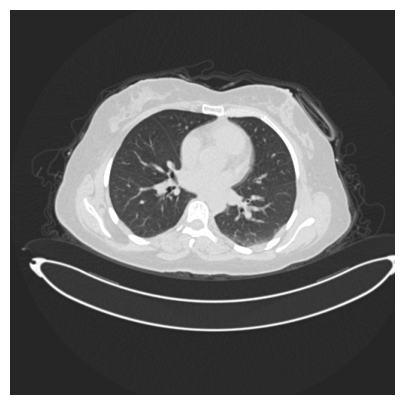

In [13]:
# Path to the image
image_path = images[500]

# Open the image using PIL
img_pil = Image.open(image_path)

# Create a figure with size 5x5 inches and display the image
plt.figure(figsize=(5, 5))
plt.imshow(img_pil)
plt.axis('off')  # Hide axes for a cleaner view
plt.show()


### Data Defining

In [14]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

In [15]:
# Define the training dataset
train = image_dataset_from_directory(
    train_path,
    labels='inferred',  # Automatically infers labels from subdirectory names
    label_mode='categorical',  # Return labels as one-hot encoded vectors
    shuffle=True,
    batch_size=BATCH_SIZE, # make some batches
    image_size=IMG_SIZE, # resize the images for simplified training
    validation_split=0.2,  # 20% for validation
    subset='training',
    seed=42
)

# Define the validation dataset
validation = image_dataset_from_directory(
    train_path,
    labels='inferred',  # Automatically infers labels from subdirectory names
    label_mode='categorical',  # Return labels as one-hot encoded vectors
    shuffle=True,
    batch_size=BATCH_SIZE, # make some batches
    image_size=IMG_SIZE, # resize the images for simplified training
    validation_split=0.2,  # 20% for validation
    subset='validation',
    seed=42
)

Found 877 files belonging to 3 classes.
Using 702 files for training.


I0000 00:00:1748588223.668774      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748588223.669465      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 877 files belonging to 3 classes.
Using 175 files for validation.


In [16]:
classes = train.class_names # Three Ckasses, so we are going to use softmax activation function
classes

['benign', 'malignant', 'normal']

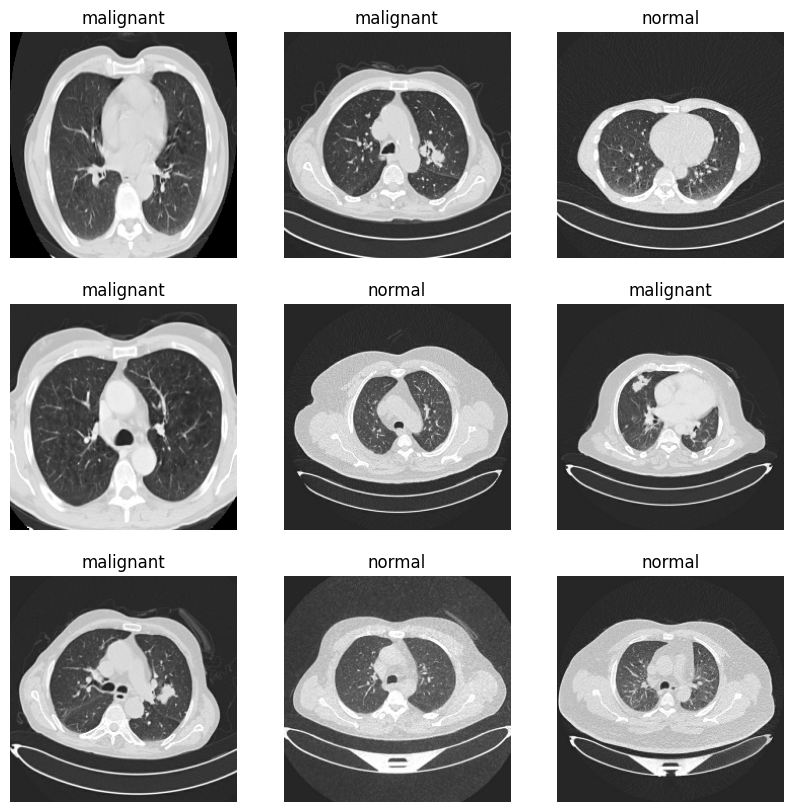

In [17]:
# Verify the dataset structure and plot some examples
plt.figure(figsize=(10, 10))
for images, labels in train.take(2):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = tf.argmax(labels[i]).numpy()  # Get the index of the highest value (class)
        plt.title(classes[label_index])
        plt.axis("off")


<a id="setup"></a>
# <b><p style="background-image: url(https://i.postimg.cc/XYnW47Zj/cover1.jpg);background-size: cover;font-family:tahoma;font-size:120%;color:white;text-align:center;border-radius:15px 50px; padding:7px; border:solid 2px #09375b; box-shadow: 10px 10px 10px #042b4c">Step 3 | Modelling</p></b>

[🏠 Tabel of Contents](#content)<a id="setup"></a>

## Model Creation

### Params Defining

In [18]:
# Automatically tune the performance by adjusting the buffer size for optimal data prefetching
AUTOTUNE = tf.data.experimental.AUTOTUNE

# Prefetch the data to improve performance by overlapping data preprocessing and model training
# This helps reduce the idle time during training
train = train.prefetch(buffer_size=AUTOTUNE)

# Preprocessing function for the input image data, specific to the ResNet50 model
# It ensures the input data is in the correct format for ResNet50 (e.g., scaling pixel values)
preprocess_input = tf.keras.applications.resnet50.preprocess_input


# Define the path to the images folder within the Kaggle environment
# This path will be used to load the dataset from a directory
path = "train"

# Define the batch size for loading data
# Batching helps in efficiently training the model by processing images in batches rather than individually
BATCH_SIZE = 32

# Define the target image size for resizing images before feeding them into the model
# This ensures all images have consistent dimensions for training (224x224 is the standard for many models like ResNet)
IMG_SIZE = (224, 224)

# Dropout rate specifies the fraction of input units to drop during training.
# A rate of 0.5 means 50% of the units will be randomly set to zero during training to prevent overfitting.
dropout_rate = 0.5

# Learning rate defines the step size used during the optimization process.
# A learning rate of 0.001 is commonly used for models like ResNet and helps the model converge slowly but steadily.
learning_rate = 0.001

# Define the input shape for the model, combining the image size and the number of color channels
input_shape = IMG_SIZE + (3,)

### ResNet50 

In [19]:
# Define the input image shape with (3,) meaning RGB structure of the image.
IMG_SHAPE = IMG_SIZE + (3,)

# Loading the ResNet50 model without the top(dense layer), including the imagenet weights
base_model = ResNet50(input_shape=IMG_SHAPE,include_top=False, weights='imagenet')

# Trainable model to fine tune the layers
base_model.trainable = True  # Enable fine-tuning

# Freeze layers up to the 150th layer leaving the rest to be trained.
fine_tune_at = 150
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [20]:
# Check Model Layers without the Top (Dense Layer)
no_layers = len(base_model.layers)


print("Number of layers without the top:", no_layers)

Number of layers without the top: 175


In [21]:
# Create the Sequential model in order to save it on .h5 format
model = Sequential()

# Data Augmentation Layers
model.add(RandomFlip('horizontal', input_shape=input_shape))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomContrast(0.2))

# Add the base model to Sequential
model.add(base_model)

# Add feature extraction parts (pooling, dropout, and output layers) 
model.add(GlobalAveragePooling2D())
model.add(Dropout(dropout_rate)) # dropout_rate as we mentioned above
model.add(Dense(units=len(classes), kernel_regularizer=l2(0.01), activation='softmax'))
# Compile the model
model.compile(optimizer=Adam(learning_rate=learning_rate),
              loss=CategoricalCrossentropy(from_logits=False),  # Set from_logits to False for softmax
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast (RandomContrast)     │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │           6,147 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 9,996,291 (38.13 MB)

 Non-trainable params: 13,597,568 (51.87 MB)

In [23]:
history = model.fit(train ,epochs=15, validation_data = validation, verbose=1)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.9570 - loss: 0.1360 - val_accuracy: 0.8571 - val_loss: 0.4208
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.9482 - loss: 0.1354 - val_accuracy: 0.8514 - val_loss: 0.7544
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.9691 - loss: 0.1131 - val_accuracy: 0.7657 - val_loss: 0.9564
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step - accuracy: 0.9554 - loss: 0.1545 - val_accuracy: 0.8457 - val_loss: 0.6877
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.9467 - loss: 0.1672 - val_accuracy: 0.8571 - val_loss: 0.5911
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.9398 - loss: 0.1831 - val_accuracy: 0.9086 - val_loss: 0.3030
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.9673 - loss: 0.1197 - val_accuracy: 0.8914 - val_loss: 0.4855
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.9663 - loss: 0.1061 - val_accuracy: 0.